In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Vanh/data_cleaning/data_after_fill_missing.csv")
print(f"Original shape: {df.shape}")
df.head()


Original shape: (19170, 51)


,room_type_id,large_double_bed,large_bed,single_bed,sofa_bed,double_bed,small_double_bed,king_size_bed,futon_mattress,bunk_bed,...,wifi_miễn_phí,không_hoàn_tiền,miễn_phí_hủy,vào_hồ_bơi_miễn_phí,đã_kèm_bữa_sáng,hotel_id,room_room_type_name,hotel_name,hotel_address,region
0,1.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,71897952.0,Phòng Deluxe Có Giường Cỡ King (Deluxe King Room),Nha Nghi Nhung - Nhung Motel,"73 Đoàn Thị Điểm, Bà Rịa, Bà Rịa, Việt Nam",Bà Rịa
1,2.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,49685029.0,Phòng Tiêu Chuẩn (Standard Room),Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),"KDC Baria City Gate, Long Huong Ward, Ba Ria C...",Bà Rịa
2,3.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,49685029.0,Phòng gia đình có ban công (Family Room with B...,Nhà nghỉ Ruby Bà Rịa (Ruby Motel Bà Rịa),"KDC Baria City Gate, Long Huong Ward, Ba Ria C...",Bà Rịa
3,4.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,65481766.0,Phòng Có Giường Cỡ King Với Ban Công (King Roo...,Baly Hotel Bà Rịa City (Baly Hotel Ba Ria City),"QL51, Bà Rịa, Bà Rịa, Việt Nam",Bà Rịa
4,5.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,5808626.0,Phòng Studio Executive (Studio Executive),Citadines Central Bình Dương (Citadines Centra...,"Số 328C, Đại lộ B nh Dương, Khu phố Hưng Lộc, ...",Bình Dương


In [8]:
# Drop missing values and duplicates
missing_before = df.isnull().sum().sum()
duplicates_before = df.duplicated().sum()

df.drop(columns=["room_type_id", "hotel_id", "room_room_type_name", "hotel_name", "hotel_address"], inplace=True, errors='ignore')
df = df.dropna()
df = df.drop_duplicates()

missing_dropped = missing_before - df.isnull().sum().sum()
duplicates_dropped = duplicates_before - df.duplicated().sum()

print(f"Số lượng missing values đã drop: {missing_dropped}")
print(f"Số lượng duplicates đã drop: {duplicates_dropped}")
print(f"Shape sau khi xử lý: {df.shape}")


Số lượng missing values đã drop: 0
Số lượng duplicates đã drop: 0
Shape sau khi xử lý: (18556, 46)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

TARGET_COL = "price_option_price"

numerical_cols = [
    'flexibility_score', 'sqm', 'bathroom_count', 
    'bedroom_count', 'adults_number', 'children_number'
]

binary_cols = [
    'large_double_bed', 'large_bed', 'single_bed', 'sofa_bed', 'double_bed',
    'small_double_bed', 'king_size_bed', 'futon_mattress', 'bunk_bed',
    'is_private_bathroom', 'balcony-terrace', 'closet', 'air_conditioning', 
    'hair_dryer', 'complimentary-bottled-water', 'bathtub', 'shower', 
    'refrigerator', 'high-floor', 'dressing-room', 'ground-floor', 'private-pool',
    'top-floor', 'complimentary-instant-coffee', 'electric-blanket', 
    'free-welcome-drink', 'low-floor', 'complimentary-tea', 'coffee-tea-maker', 
    'hot-spring-access', 'bãi_đậu_xe', 'phòng_tập', 'wifi_miễn_phí', 'không_hoàn_tiền', 
    'miễn_phí_hủy', 'vào_hồ_bơi_miễn_phí', 'đã_kèm_bữa_sáng'
]

categorical_cols = [
    "views",
    "region"
]

X = df[numerical_cols + binary_cols + categorical_cols].copy()
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (14844, 45), Test shape: (3712, 45)


In [10]:
# Prepare data for different models
# For sklearn models (Linear, Ridge, Lasso, Random Forest) - use OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train_sklearn = preprocessor.fit_transform(X_train)
X_test_sklearn = preprocessor.transform(X_test)

# For tree-based models - use LabelEncoder
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

le_views = LabelEncoder()
le_region = LabelEncoder()
X_train_tree['views'] = le_views.fit_transform(X_train_tree['views'])
X_test_tree['views'] = le_views.transform(X_test_tree['views'])
X_train_tree['region'] = le_region.fit_transform(X_train_tree['region'])
X_test_tree['region'] = le_region.transform(X_test_tree['region'])

# For CatBoost - keep categorical as is
cat_indices = [X_train.columns.get_loc(col) for col in categorical_cols]


In [11]:
def calculate_metrics(y_true, y_pred, model_name, split='test'):
    """Calculate and return metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Split': split,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

results = []


In [12]:
# 1. Linear Regression
print("Training Linear Regression...")
model_lr = LinearRegression()
model_lr.fit(X_train_sklearn, y_train)

y_train_pred_lr = model_lr.predict(X_train_sklearn)
y_test_pred_lr = model_lr.predict(X_test_sklearn)

results.append(calculate_metrics(y_train, y_train_pred_lr, "Linear Regression", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_lr, "Linear Regression", "Test"))
print("✓ Linear Regression completed")


Training Linear Regression...
✓ Linear Regression completed


In [13]:
# 2. Ridge Regression
print("Training Ridge Regression...")
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_sklearn, y_train)

y_train_pred_ridge = model_ridge.predict(X_train_sklearn)
y_test_pred_ridge = model_ridge.predict(X_test_sklearn)

results.append(calculate_metrics(y_train, y_train_pred_ridge, "Ridge Regression", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_ridge, "Ridge Regression", "Test"))
print("✓ Ridge Regression completed")


Training Ridge Regression...
✓ Ridge Regression completed


In [14]:
# 3. Lasso Regression
print("Training Lasso Regression...")
model_lasso = Lasso(alpha=0.001, max_iter=10000)
model_lasso.fit(X_train_sklearn, y_train)

y_train_pred_lasso = model_lasso.predict(X_train_sklearn)
y_test_pred_lasso = model_lasso.predict(X_test_sklearn)

results.append(calculate_metrics(y_train, y_train_pred_lasso, "Lasso Regression", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_lasso, "Lasso Regression", "Test"))
print("✓ Lasso Regression completed")


Training Lasso Regression...


✓ Lasso Regression completed


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.095e+17, tolerance: 6.316e+13
  model = cd_fast.enet_coordinate_descent(


In [15]:
# 4. Random Forest
print("Training Random Forest...")
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_sklearn, y_train)

y_train_pred_rf = model_rf.predict(X_train_sklearn)
y_test_pred_rf = model_rf.predict(X_test_sklearn)

results.append(calculate_metrics(y_train, y_train_pred_rf, "Random Forest", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_rf, "Random Forest", "Test"))
print("✓ Random Forest completed")


Training Random Forest...
✓ Random Forest completed


In [16]:
# 5. XGBoost
print("Training XGBoost...")
model_xgb = xgb.XGBRegressor(random_state=42, n_estimators=100, n_jobs=-1)
model_xgb.fit(X_train_tree, y_train)

y_train_pred_xgb = model_xgb.predict(X_train_tree)
y_test_pred_xgb = model_xgb.predict(X_test_tree)

results.append(calculate_metrics(y_train, y_train_pred_xgb, "XGBoost", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_xgb, "XGBoost", "Test"))
print("✓ XGBoost completed")


Training XGBoost...
✓ XGBoost completed


In [17]:
# 6. LightGBM
print("Training LightGBM...")
model_lgb = lgb.LGBMRegressor(random_state=42, n_estimators=100, verbose=-1, n_jobs=-1)
model_lgb.fit(X_train_tree, y_train)

y_train_pred_lgb = model_lgb.predict(X_train_tree)
y_test_pred_lgb = model_lgb.predict(X_test_tree)

results.append(calculate_metrics(y_train, y_train_pred_lgb, "LightGBM", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_lgb, "LightGBM", "Test"))
print("✓ LightGBM completed")


Training LightGBM...
✓ LightGBM completed


In [18]:
# 7. CatBoost
print("Training CatBoost...")
model_cat = CatBoostRegressor(random_state=42, iterations=100, verbose=False, cat_features=cat_indices)
model_cat.fit(X_train, y_train)

y_train_pred_cat = model_cat.predict(X_train)
y_test_pred_cat = model_cat.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred_cat, "CatBoost", "Train"))
results.append(calculate_metrics(y_test, y_test_pred_cat, "CatBoost", "Test"))
print("✓ CatBoost completed")


Training CatBoost...
✓ CatBoost completed


In [19]:
# Create comparison table
results_df = pd.DataFrame(results)
results_df['MAE'] = results_df['MAE'].apply(lambda x: f"{x:.3e}")
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f"{x:.3e}")
results_df['R2'] = results_df['R2'].apply(lambda x: f"{x:.4f}")

print("\n" + "="*80)
print("BẢNG SO SÁNH METRICS GIỮA CÁC MODEL")
print("="*80)
display(results_df)



BẢNG SO SÁNH METRICS GIỮA CÁC MODEL


,Model,Split,MAE,RMSE,R2
0,Linear Regression,Train,1.178e+06,6.418e+06,0.0318
1,Linear Regression,Test,1.093e+06,2.235e+06,0.1660
2,Ridge Regression,Train,1.178e+06,6.418e+06,0.0318
3,Ridge Regression,Test,1.092e+06,2.235e+06,0.1660
4,Lasso Regression,Train,1.178e+06,6.418e+06,0.0318
5,Lasso Regression,Test,1.093e+06,2.235e+06,0.1660
6,Random Forest,Train,4.673e+05,5.282e+06,0.3443
7,Random Forest,Test,9.303e+05,5.013e+06,-3.1970
8,XGBoost,Train,6.748e+05,5.393e+06,0.3165
9,XGBoost,Test,9.524e+05,2.920e+06,-0.4243


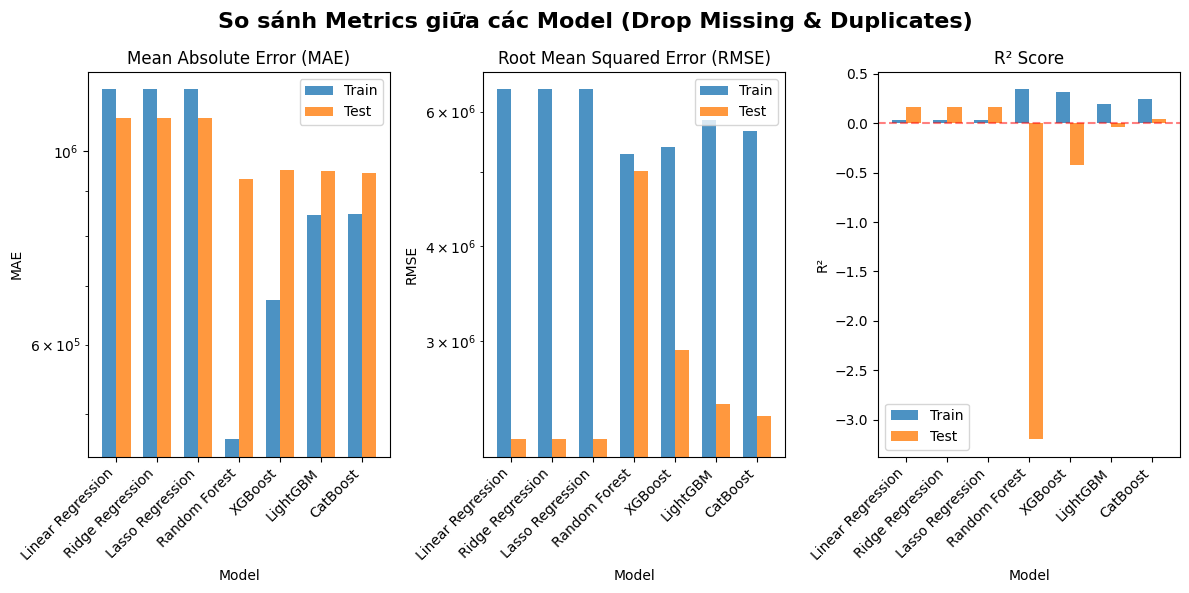

In [20]:
# Prepare data for visualization
results_viz = pd.DataFrame(results)
results_viz_pivot = results_viz.pivot(index='Model', columns='Split', values=['MAE', 'RMSE', 'R2'])

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
fig.suptitle('So sánh Metrics giữa các Model (Drop Missing & Duplicates)', fontsize=16, fontweight='bold')

models = results_viz['Model'].unique()
x = np.arange(len(models))
width = 0.35

# MAE
ax1 = axes[0]
train_mae = [results_viz[(results_viz['Model']==m) & (results_viz['Split']=='Train')]['MAE'].values[0] for m in models]
test_mae = [results_viz[(results_viz['Model']==m) & (results_viz['Split']=='Test')]['MAE'].values[0] for m in models]
ax1.bar(x - width/2, train_mae, width, label='Train', alpha=0.8)
ax1.bar(x + width/2, test_mae, width, label='Test', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('MAE')
ax1.set_title('Mean Absolute Error (MAE)')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.set_yscale('log')

# RMSE
ax2 = axes[1]
train_rmse = [results_viz[(results_viz['Model']==m) & (results_viz['Split']=='Train')]['RMSE'].values[0] for m in models]
test_rmse = [results_viz[(results_viz['Model']==m) & (results_viz['Split']=='Test')]['RMSE'].values[0] for m in models]
ax2.bar(x - width/2, train_rmse, width, label='Train', alpha=0.8)
ax2.bar(x + width/2, test_rmse, width, label='Test', alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('RMSE')
ax2.set_title('Root Mean Squared Error (RMSE)')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()
ax2.set_yscale('log')

# R2
ax3 = axes[2]
train_r2 = [results_viz[(results_viz['Model']==m) & (results_viz['Split']=='Train')]['R2'].values[0] for m in models]
test_r2 = [results_viz[(results_viz['Model']==m) & (results_viz['Split']=='Test')]['R2'].values[0] for m in models]
ax3.bar(x - width/2, train_r2, width, label='Train', alpha=0.8)
ax3.bar(x + width/2, test_r2, width, label='Test', alpha=0.8)
ax3.set_xlabel('Model')
ax3.set_ylabel('R²')
ax3.set_title('R² Score')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.legend()
ax3.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


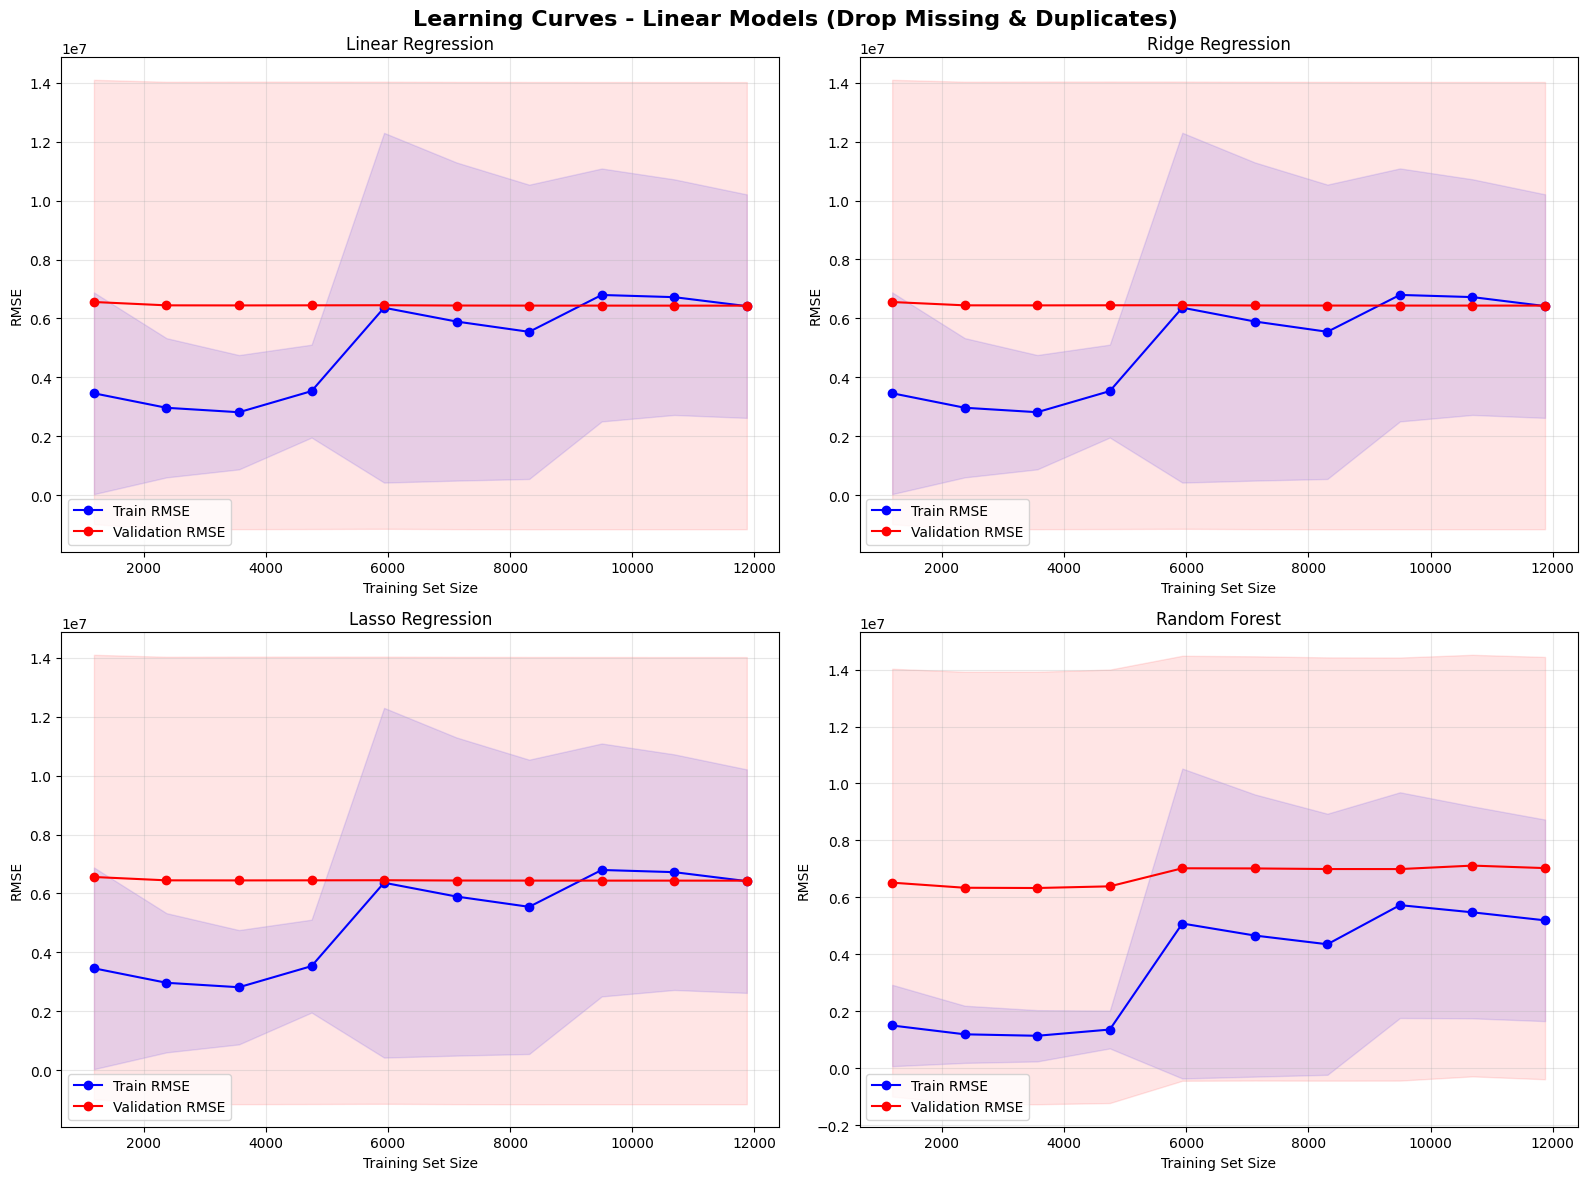

In [21]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax, train_sizes=np.linspace(0.1, 1.0, 10)):
    """Plot learning curve for a model"""
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y, 
        train_sizes=train_sizes,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    train_scores_mean = np.sqrt(-train_scores.mean(axis=1))
    train_scores_std = np.sqrt(train_scores.std(axis=1)) # Std của MSE không trực tiếp thành Std của RMSE bằng cách căn bậc 2, nhưng để visualize đơn giản dải dao động thì tạm chấp nhận hoặc tính lại std trên RMSE gốc.
    
    val_scores_mean = np.sqrt(-val_scores.mean(axis=1))
    val_scores_std = np.sqrt(val_scores.std(axis=1))
    
    ax.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes_abs, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color='red')
    ax.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Train RMSE')
    ax.plot(train_sizes_abs, val_scores_mean, 'o-', color='red', label='Validation RMSE')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax

# Create learning curves for sklearn models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Learning Curves - Linear Models (Drop Missing & Duplicates)', fontsize=16, fontweight='bold')

plot_learning_curve(LinearRegression(), X_train_sklearn, y_train, 'Linear Regression', axes[0, 0])
plot_learning_curve(Ridge(alpha=1.0), X_train_sklearn, y_train, 'Ridge Regression', axes[0, 1])
plot_learning_curve(Lasso(alpha=0.001, max_iter=10000), X_train_sklearn, y_train, 'Lasso Regression', axes[1, 0])
plot_learning_curve(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), 
                    X_train_sklearn, y_train, 'Random Forest', axes[1, 1])

plt.tight_layout()
plt.show()


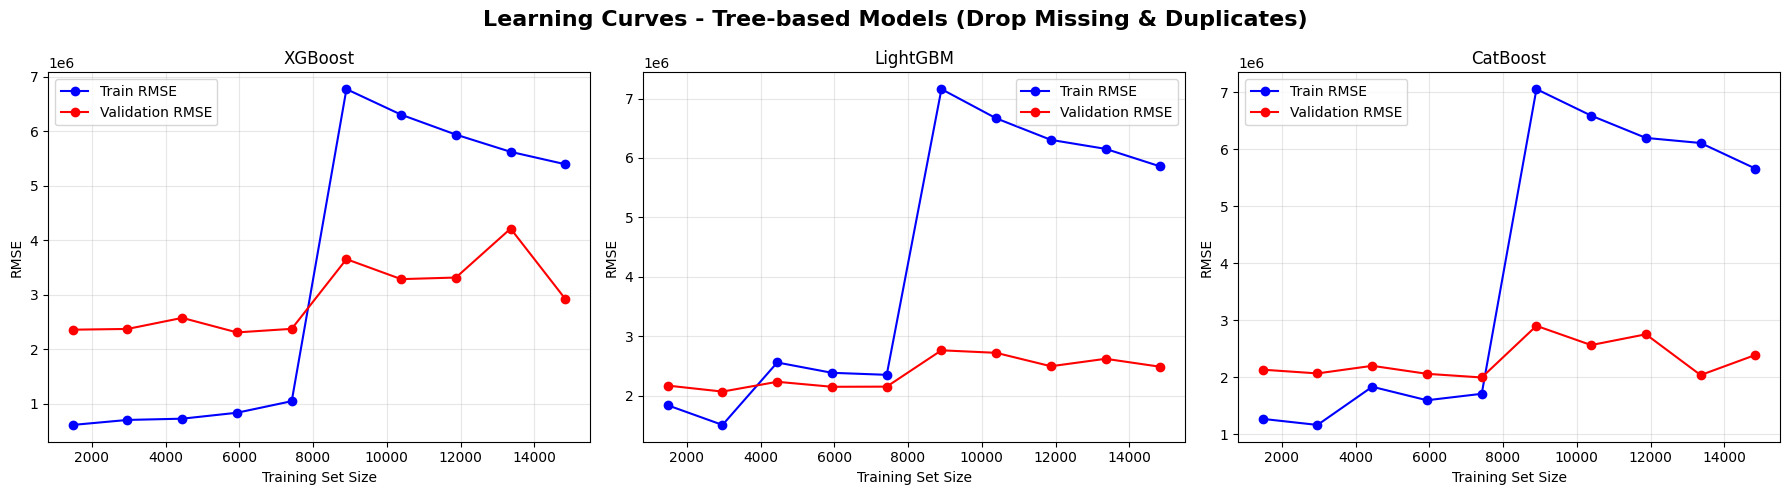

In [22]:
# Learning curves for tree-based models using incremental training
def plot_tree_learning_curve(model_class, X_train, y_train, X_test, y_test, title, ax, **model_params):
    """Plot learning curve for tree-based models"""
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_rmse_list = []
    val_rmse_list = []
    
    for size in train_sizes:
        n_samples = int(len(X_train) * size)
        X_subset = X_train[:n_samples]
        y_subset = y_train[:n_samples]
        
        model = model_class(**model_params)
        model.fit(X_subset, y_subset)
        
        train_pred = model.predict(X_subset)
        val_pred = model.predict(X_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_subset, train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_test, val_pred))
        
        train_rmse_list.append(train_rmse)
        val_rmse_list.append(val_rmse)
    
    train_sizes_abs = [int(len(X_train) * size) for size in train_sizes]
    ax.plot(train_sizes_abs, train_rmse_list, 'o-', color='blue', label='Train RMSE')
    ax.plot(train_sizes_abs, val_rmse_list, 'o-', color='red', label='Validation RMSE')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves - Tree-based Models (Drop Missing & Duplicates)', fontsize=16, fontweight='bold')

plot_tree_learning_curve(xgb.XGBRegressor, X_train_tree, y_train, X_test_tree, y_test, 
                         'XGBoost', axes[0], random_state=42, n_estimators=100, n_jobs=-1)
plot_tree_learning_curve(lgb.LGBMRegressor, X_train_tree, y_train, X_test_tree, y_test, 
                         'LightGBM', axes[1], random_state=42, n_estimators=100, verbose=-1, n_jobs=-1)
plot_tree_learning_curve(CatBoostRegressor, X_train, y_train, X_test, y_test, 
                         'CatBoost', axes[2], random_state=42, iterations=100, verbose=False, cat_features=cat_indices)

plt.tight_layout()
plt.show()
